In [0]:
pip install nflreadpy

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import nflreadpy as nfl
pbp_reg = nfl.load_pbp(range(2015, 2026))

In [0]:
pbp_reg.columns

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

In [0]:
import polars as pl
pbp_reg = pbp_reg.filter(pl.col("season_type") == "REG")

In [0]:
# ── Passing
passing = (
    pbp_reg.filter(pl.col("passer_player_id").is_not_null())
    .group_by("passer_player_id", "passer_player_name", "season")
    .agg(
        (pl.col("complete_pass").sum() + pl.col("incomplete_pass").sum()).alias("pass_attempts"),
        pl.col("complete_pass").sum().alias("completions"),
        pl.col("passing_yards").sum().alias("pass_yards"),
        pl.col("pass_touchdown").sum().alias("pass_tds"),
        pl.col("interception").sum().alias("interceptions"),
        pl.col("sack").sum().alias("sacks"),
        pl.col("epa").mean().alias("pass_epa_per_play"),
        pl.col("epa").sum().alias("pass_total_epa"),
    )
    .with_columns([
    pl.when(pl.col("pass_attempts") > 0).then(pl.col("completions") / pl.col("pass_attempts")).otherwise(0).alias("completion_pct"),
    pl.when(pl.col("pass_attempts") > 0).then(pl.col("pass_yards") / pl.col("pass_attempts")).otherwise(0).alias("yards_per_attempt"),
    pl.when(pl.col("pass_attempts") > 0).then(pl.col("pass_tds") / pl.col("pass_attempts")).otherwise(0).alias("pass_td_rate"),
    pl.when(pl.col("pass_attempts") > 0).then(pl.col("interceptions") / pl.col("pass_attempts")).otherwise(0).alias("int_rate"),
])
    .rename({"passer_player_id": "player_id", "passer_player_name": "player_name"})
)

In [0]:
# ── Rushing
rushing = (
    pbp_reg.filter(pl.col("rusher_player_id").is_not_null())
    .group_by("rusher_player_id", "rusher_player_name", "season")
    .agg(
        pl.col("rush_attempt").sum().alias("carries"),
        pl.col("rushing_yards").sum().alias("rush_yards"),
        pl.col("rush_touchdown").sum().alias("rush_tds"),
        (pl.col("rushing_yards") >= 10).sum().alias("explosive_runs"),
        pl.col("fumble").sum().alias("rush_fumbles"),
        pl.col("epa").mean().alias("rush_epa_per_play"),
        pl.col("epa").sum().alias("rush_total_epa"),
    )
    .with_columns([
    pl.when(pl.col("carries") > 0).then(pl.col("rush_yards") / pl.col("carries")).otherwise(0).alias("yards_per_carry"),
    pl.when(pl.col("carries") > 0).then(pl.col("rush_tds") / pl.col("carries")).otherwise(0).alias("rush_td_rate"),
    pl.when(pl.col("carries") > 0).then(pl.col("explosive_runs") / pl.col("carries")).otherwise(0).alias("explosive_run_rate"),
    pl.when(pl.col("carries") > 0).then(pl.col("rush_fumbles") / pl.col("carries")).otherwise(0).alias("fumble_rate"),
])
    .rename({"rusher_player_id": "player_id", "rusher_player_name": "player_name"})
)

In [0]:
# ── Receiving 
receiving = (
    pbp_reg.filter(pl.col("receiver_player_id").is_not_null())
    .group_by("receiver_player_id", "receiver_player_name", "season")
    .agg(
        pl.col("pass_attempt").sum().alias("targets"),
        pl.col("complete_pass").sum().alias("receptions"),
        pl.col("receiving_yards").sum().alias("rec_yards"),
        pl.col("pass_touchdown").sum().alias("rec_tds"),
        (pl.col("receiving_yards") >= 20).sum().alias("explosive_recs"),
        pl.col("fumble").sum().alias("rec_fumbles"),
        pl.col("air_yards").sum().alias("air_yards"),
        pl.col("yards_after_catch").sum().alias("yac"),
        pl.col("epa").mean().alias("rec_epa_per_play"),
        pl.col("epa").sum().alias("rec_total_epa"),
    )
    .with_columns([
    pl.when(pl.col("targets") > 0).then(pl.col("receptions") / pl.col("targets")).otherwise(0).alias("catch_rate"),
    pl.when(pl.col("receptions") > 0).then(pl.col("rec_yards") / pl.col("receptions")).otherwise(0).alias("yards_per_rec"),
    pl.when(pl.col("targets") > 0).then(pl.col("rec_tds") / pl.col("targets")).otherwise(0).alias("rec_td_rate"),
    pl.when(pl.col("receptions") > 0).then(pl.col("explosive_recs") / pl.col("receptions")).otherwise(0).alias("explosive_rec_rate"),
    pl.when(pl.col("targets") > 0).then(pl.col("air_yards") / pl.col("targets")).otherwise(0).alias("air_yards_per_target"),
    pl.when(pl.col("receptions") > 0).then(pl.col("yac") / pl.col("receptions")).otherwise(0).alias("yac_per_rec"),
])
    .rename({"receiver_player_id": "player_id", "receiver_player_name": "player_name"})
)

In [0]:
# Compute games_played once across all play types
games_played = pl.concat([
    pbp_reg.filter(pl.col("passer_player_id").is_not_null())
        .select(pl.col("passer_player_id").alias("player_id"), "season", "game_id"),
    pbp_reg.filter(pl.col("rusher_player_id").is_not_null())
        .select(pl.col("rusher_player_id").alias("player_id"), "season", "game_id"),
    pbp_reg.filter(pl.col("receiver_player_id").is_not_null())
        .select(pl.col("receiver_player_id").alias("player_id"), "season", "game_id"),
]).group_by("player_id", "season").agg(
    pl.col("game_id").n_unique().alias("games_played")
)

In [0]:
# ── Combine into one row per player per season 
# Start from the union of all player/season combos
all_players = pl.concat([
    passing.select("player_id", "player_name", "season"),
    rushing.select("player_id", "player_name", "season"),
    receiving.select("player_id", "player_name", "season"),
]).unique()

player_season = (
    all_players
    .join(passing.drop("player_name"),   on=["player_id", "season"], how="left")
    .join(rushing.drop("player_name"),   on=["player_id", "season"], how="left")
    .join(receiving.drop("player_name"), on=["player_id", "season"], how="left")
    .join(games_played, on=["player_id", "season"], how="left")
    .fill_null(0)
)

In [0]:
contracts = nfl.load_contracts()
contracts.columns

['player',
 'position',
 'team',
 'is_active',
 'year_signed',
 'years',
 'value',
 'apy',
 'guaranteed',
 'apy_cap_pct',
 'inflated_value',
 'inflated_apy',
 'inflated_guaranteed',
 'player_page',
 'otc_id',
 'gsis_id',
 'date_of_birth',
 'height',
 'weight',
 'college',
 'draft_year',
 'draft_round',
 'draft_overall',
 'draft_team',
 'cols']

In [0]:
contracts_clean = contracts.filter(
    pl.col("gsis_id").is_not_null()
).select([
    "gsis_id",
    "player",
    "position",
    "year_signed",
    "years",
    "value",
    "apy",
    "guaranteed",
    "is_active",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed",
    "draft_round",
    "draft_overall",
    "draft_year"
]).with_columns([
    # If the year they signed equals the year they were drafted, it's a rookie deal!
    pl.when(pl.col("year_signed") == pl.col("draft_year"))
    .then(1)
    .otherwise(0)
    .alias("is_rookie_contract")
])

In [0]:
contracts_clean = contracts_clean.with_columns([
    (pl.col("year_signed") + pl.col("years") - 1).alias("year_end")
])
contracts_clean.head()

gsis_id,player,position,year_signed,years,value,apy,guaranteed,is_active,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,draft_round,draft_overall,draft_year,is_rookie_contract,year_end
str,str,str,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,i32,i32,i32,i32
"""00-0036442""","""Joe Burrow""","""QB""",2023,5,275.0,55.0,146.51,true,0.245,368.460854,73.692171,196.302544,1,1,2020,0,2027
"""00-0023459""","""Aaron Rodgers""","""QB""",2022,5,150.815,50.271667,101.415,false,0.241,218.181931,72.727311,146.715648,1,24,2005,0,2026
"""00-0034857""","""Josh Allen""","""QB""",2021,6,258.0,43.0,100.0,false,0.236,425.806027,70.967671,165.041096,1,7,2018,0,2026
"""00-0029263""","""Russell Wilson""","""QB""",2022,5,245.0,49.0,124.0,false,0.235,354.43804,70.887608,179.389049,3,75,2012,0,2026
"""00-0033077""","""Dak Prescott""","""QB""",2024,4,240.0,60.0,129.0,true,0.235,283.038371,70.759593,152.133125,4,135,2016,0,2027


In [0]:
contracts_clean = contracts_clean.sort(["gsis_id", "year_signed"], descending=[False, True])

In [0]:
next_contracts = contracts_clean.select([
    "gsis_id",
    "player",
    "year_signed",
    "apy",
    "years",
    "value",
    "guaranteed",
    "is_active",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed",
    "draft_round",
    "draft_overall"
]).rename({
    "year_signed": "next_year_signed",
    "apy": "next_apy",
    "years": "next_years",
    "value": "next_value",
    "guaranteed": "next_guaranteed",
    "apy_cap_pct": "next_apy_cap_pct",
    "inflated_value": "next_inflated_value",
    "inflated_apy": "next_inflated_apy",
    "inflated_guaranteed": "next_inflated_guaranteed",
})
next_contracts.head()

gsis_id,player,next_year_signed,next_apy,next_years,next_value,next_guaranteed,is_active,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,draft_round,draft_overall
str,str,i32,f64,i32,f64,f64,bool,f64,f64,f64,f64,i32,i32
"""00-0000108""","""David Akers""",0,1.005,1,1.005,0.1,false,0.0,0.0,0.0,0.0,null,null
"""00-0000585""","""Champ Bailey""",2014,1.875,2,3.75,0.5,false,0.014,8.492481,4.246241,1.132331,1,7
"""00-0000585""","""Champ Bailey""",2011,10.75,4,43.0,10.5,false,0.089,107.593769,26.898442,26.272897,1,7
"""00-0000585""","""Champ Bailey""",2004,9.004575,7,63.032025,6.0,false,0.112,235.601573,33.657368,22.426845,1,7
"""00-0000585""","""Champ Bailey""",2004,6.801,1,6.801,6.801,false,0.084,25.420828,25.420828,25.420828,1,7


In [0]:
next_contracts_clean = (
    next_contracts
    .sort(["gsis_id", "next_year_signed", "next_apy"])
    .group_by(["gsis_id", "next_year_signed"])
    .agg(pl.all().last())
)

In [0]:
# 1. join all contracts to all seasons
joined = player_season.join(
    next_contracts_clean,
    left_on="player_id",
    right_on="gsis_id",
    how="left"
)

# 2. keep only future contracts
future = joined.filter(
    pl.col("next_year_signed").is_null() | 
    (pl.col("next_year_signed") > pl.col("season"))
)

# 3. pick closest future contract
final = (
    future
    .sort(["player_id", "season", "next_year_signed"])
    .group_by(["player_id", "season"])
    .agg(pl.all().first())
)

In [0]:
# season → final contract in that season → next contract in a later season

In [0]:
current_contracts = contracts_clean.rename({
    "year_signed": "curr_year_signed",
    "apy": "curr_apy",
    "years": "curr_years",
    "value": "curr_value",
    "guaranteed": "curr_guaranteed",
    "apy_cap_pct": "curr_apy_cap_pct",
    "inflated_value": "curr_inflated_value",
    "inflated_apy": "curr_inflated_apy",
    "inflated_guaranteed": "curr_inflated_guaranteed",
})

In [0]:
contracts_clean = contracts_clean.filter(
    ~((pl.col("years") == 1) & 
      (pl.col("guaranteed") == 0) & 
      (pl.col("apy") > 5))  # tags are always significant money
)

In [0]:
contract_events = (
    contracts_clean
    .sort(["gsis_id", "year_signed"])
    .with_columns([
        pl.col("year_signed").shift(-1).over("gsis_id").alias("next_year_signed"),
        pl.col("apy").shift(-1).over("gsis_id").alias("next_apy"),
        pl.col("years").shift(-1).over("gsis_id").alias("next_years"),
        pl.col("value").shift(-1).over("gsis_id").alias("next_value"),
        pl.col("guaranteed").shift(-1).over("gsis_id").alias("next_guaranteed"),
        pl.col("apy_cap_pct").shift(-1).over("gsis_id").alias("next_apy_cap_pct"),
        pl.col("inflated_value").shift(-1).over("gsis_id").alias("next_inflated_value"),
        pl.col("inflated_apy").shift(-1).over("gsis_id").alias("next_inflated_apy"),
        pl.col("inflated_guaranteed").shift(-1).over("gsis_id").alias("next_inflated_guaranteed"),
    ])
    .rename({
        "gsis_id": "player_id",
        "year_signed": "curr_year_signed",
        "years": "curr_years",
        "value": "curr_value",
        "apy": "curr_apy",
        "guaranteed": "curr_guaranteed",
        "apy_cap_pct": "curr_apy_cap_pct",
        "inflated_value": "curr_inflated_value",
        "inflated_apy": "curr_inflated_apy",
        "inflated_guaranteed": "curr_inflated_guaranteed",
    })
)

contract_events = contract_events.with_columns(
    pl.arange(0, pl.len()).over("player_id").alias("contract_idx")
)

contract_events = contract_events.with_columns(
    pl.when(pl.col("next_year_signed").is_not_null())
      .then(pl.col("next_year_signed"))
      .otherwise(2026)  # <-- key decision
      .alias("anchor_year")
)

In [0]:
players = nfl.load_players()
# ── STEP 2: Compute next_season_age once per contract event ───────────────────
players_pl = (
    players.select(['gsis_id', 'birth_date'])
    .unique()
    .rename({'gsis_id': 'player_id'})
    .with_columns(pl.col('birth_date').cast(pl.Date))
)

contract_events = (
    contract_events.join(players_pl, on='player_id', how='left')
    .with_columns(
        (
            (
                pl.date(pl.col('anchor_year'), 9, 1)
                - pl.col('birth_date')
            ).dt.total_days() / 365.25
        ).round(1).alias('next_season_age')
    ).drop('birth_date')
)

In [0]:
# ── NEW PRE-STEP: Add position, calculate total EPA, and rank ─────────────────
player_season = (
    player_season
    .join(
        players.select(["gsis_id", "position"]).rename({"gsis_id": "player_id"}), 
        on="player_id", 
        how="left"
    )
    .with_columns(
        (
            pl.col("pass_total_epa").fill_null(0) + 
            pl.col("rush_total_epa").fill_null(0) + 
            pl.col("rec_total_epa").fill_null(0)
        ).alias("total_epa")
    )
    .with_columns(
        pl.col("total_epa").rank("dense", descending=True).over(["season", "position"]).alias("overall_epa_rank"),
        
        # You can keep the individual ranks too if you want the model to see how they got their EPA
        pl.col("pass_total_epa").rank("dense", descending=True).over(["season", "position"]).alias("pass_epa_rank"),
        pl.col("rush_total_epa").rank("dense", descending=True).over(["season", "position"]).alias("rush_epa_rank"),
        pl.col("rec_total_epa").rank("dense", descending=True).over(["season", "position"]).alias("rec_epa_rank"),
    )
)

# --- NEW CODE TO ADD AT BOTTOM OF CELL 21 ---
# Calculate per-game stats
volume_stats = [
    "pass_yards", "pass_tds", "carries", "rush_yards", "rush_tds", "targets", "receptions", "rec_yards", "rec_tds"
]

per_game_exprs = [
    (pl.col(stat).fill_null(0) / pl.col("games_played").clip(1)).alias(f"{stat}_per_game")
    for stat in volume_stats
]

player_season = player_season.with_columns(per_game_exprs)

In [0]:
# ── STEP 3: Build lags from the 4 seasons directly before next_year_signed ────
# lag_number is now arithmetic: next_year_signed - season
# lag_1 = season immediately before signing, lag_4 = 4 seasons before
stats_lagged = (
    player_season
    .join(
        contract_events.select(["player_id", "anchor_year", "contract_idx"]),
        on="player_id",
        how="inner"
    )
    .with_columns(
        (pl.col("anchor_year") - pl.col("season")).alias("lag_number")
    )
    .filter(
        (pl.col("lag_number") >= 1) & (pl.col("lag_number") <= 4)
    )
)


In [0]:
# ── STEP 5: Pivot stats into lag columns ──────────────────────────────────────
stat_cols = [
    "pass_attempts", "completions", "pass_yards", "pass_tds", "interceptions", "sacks",
    "pass_epa_per_play", "pass_total_epa", "completion_pct", "yards_per_attempt",
    "pass_td_rate", "int_rate", "carries", "rush_yards", "rush_tds", "explosive_runs",
    "rush_fumbles", "rush_epa_per_play", "rush_total_epa", "yards_per_carry",
    "rush_td_rate", "explosive_run_rate", "fumble_rate", "targets", "receptions",
    "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", "air_yards", "yac",
    "rec_epa_per_play", "rec_total_epa", "catch_rate", "yards_per_rec", "rec_td_rate",
    "explosive_rec_rate", "air_yards_per_target", "yac_per_rec", "games_played",
    "pass_epa_rank", "rush_epa_rank", "rec_epa_rank", "overall_epa_rank", "pass_yards_per_game", "pass_tds_per_game", "carries_per_game", "rush_yards_per_game", "rush_tds_per_game",
    "targets_per_game", "receptions_per_game", "rec_yards_per_game", "rec_tds_per_game" 
]

flattened_stats = stats_lagged.pivot(
    values=stat_cols,
    index=["player_id", "contract_idx", "anchor_year"],
    on="lag_number",
    aggregate_function="first"
)

In [0]:
# ── STEP 6: Join into final dataset ───────────────────────────────────────────
final_dataset = contract_events.join(
    flattened_stats,
    on=["player_id", "contract_idx", "anchor_year"],
    how="left"
)

In [0]:
final_dataset.filter(pl.col("player") == "Lamar Jackson", pl.col("position") == "QB") \
                 .sort("next_year_signed")

player_id,player,position,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,draft_round,draft_overall,draft_year,is_rookie_contract,year_end,next_year_signed,next_apy,next_years,next_value,next_guaranteed,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,contract_idx,anchor_year,next_season_age,pass_attempts_1,pass_attempts_3,pass_attempts_4,pass_attempts_2,completions_1,completions_3,completions_4,…,overall_epa_rank_2,pass_yards_per_game_1,pass_yards_per_game_3,pass_yards_per_game_4,pass_yards_per_game_2,pass_tds_per_game_1,pass_tds_per_game_3,pass_tds_per_game_4,pass_tds_per_game_2,carries_per_game_1,carries_per_game_3,carries_per_game_4,carries_per_game_2,rush_yards_per_game_1,rush_yards_per_game_3,rush_yards_per_game_4,rush_yards_per_game_2,rush_tds_per_game_1,rush_tds_per_game_3,rush_tds_per_game_4,rush_tds_per_game_2,targets_per_game_1,targets_per_game_3,targets_per_game_4,targets_per_game_2,receptions_per_game_1,receptions_per_game_3,receptions_per_game_4,receptions_per_game_2,rec_yards_per_game_1,rec_yards_per_game_3,rec_yards_per_game_4,rec_yards_per_game_2,rec_tds_per_game_1,rec_tds_per_game_3,rec_tds_per_game_4,rec_tds_per_game_2
str,str,str,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,f64,i32,f64,f64,f64,f64,f64,f64,i64,i32,f64,f64,f64,f64,f64,f64,f64,f64,…,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""00-0034796""","""Lamar Jackson""","""QB""",2023,5,260.0,52.0,135.0,true,0.231,348.362989,69.672598,180.880783,1,32,2018,0,2027,null,null,null,null,null,null,null,null,null,1,2026,29.6,295.0,450.0,319.0,470.0,192.0,307.0,203.0,…,2,196.076923,229.875,186.833333,245.411765,1.615385,1.5,1.416667,2.411765,5.153846,9.25,9.333333,8.235294,26.846154,51.3125,63.666667,53.823529,0.153846,0.3125,0.25,0.235294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""00-0034796""","""Lamar Jackson""","""QB""",2018,4,9.471652,2.367913,8.055062,false,0.013,16.09967,4.024918,13.691787,1,32,2018,1,2021,2023,52.0,5,260.0,135.0,0.231,348.362989,69.672598,180.880783,0,2023,26.6,319.0,367.0,395.0,369.0,203.0,242.0,265.0,…,24,186.833333,183.8,208.466667,240.166667,1.416667,1.733333,2.4,1.333333,9.333333,10.6,11.866667,11.166667,63.666667,67.0,80.4,63.916667,0.25,0.466667,0.466667,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [0]:
final_dataset.columns

['player_id',
 'player',
 'position',
 'curr_year_signed',
 'curr_years',
 'curr_value',
 'curr_apy',
 'curr_guaranteed',
 'is_active',
 'curr_apy_cap_pct',
 'curr_inflated_value',
 'curr_inflated_apy',
 'curr_inflated_guaranteed',
 'draft_round',
 'draft_overall',
 'draft_year',
 'is_rookie_contract',
 'year_end',
 'next_year_signed',
 'next_apy',
 'next_years',
 'next_value',
 'next_guaranteed',
 'next_apy_cap_pct',
 'next_inflated_value',
 'next_inflated_apy',
 'next_inflated_guaranteed',
 'contract_idx',
 'anchor_year',
 'next_season_age',
 'pass_attempts_1',
 'pass_attempts_3',
 'pass_attempts_4',
 'pass_attempts_2',
 'completions_1',
 'completions_3',
 'completions_4',
 'completions_2',
 'pass_yards_1',
 'pass_yards_3',
 'pass_yards_4',
 'pass_yards_2',
 'pass_tds_1',
 'pass_tds_3',
 'pass_tds_4',
 'pass_tds_2',
 'interceptions_1',
 'interceptions_3',
 'interceptions_4',
 'interceptions_2',
 'sacks_1',
 'sacks_3',
 'sacks_4',
 'sacks_2',
 'pass_epa_per_play_1',
 'pass_epa_per_pla

In [0]:
pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Clean and define the master df
df_clean = final_dataset.drop_nulls(subset=[
    "next_year_signed", 
    "next_inflated_apy", 
    "next_years", 
    "next_guaranteed"
])

# 1. Define the Salary Cap Mapping (Official NFL Figures)
cap_mapping = {
    2015: 143.28, 2016: 155.27, 2017: 167.0, 2018: 177.2, 
    2019: 188.2, 2020: 198.2, 2021: 182.5, 2022: 208.2, 
    2023: 224.8, 2024: 255.4, 2025: 279.2, 2026: 301.2
}

# 2. Add the column to your Polars DataFrame
df_clean = df_clean.with_columns(
    pl.col("next_year_signed").replace(cap_mapping).alias("yearly_cap")
)

In [0]:
# 1. Calculate how many years they have been in the league at the time of signing
df_clean = df_clean.with_columns([
    (pl.col("next_year_signed") - pl.col("draft_year")).alias("career_year_at_signing")
])

# 2. Create the binary Rookie Contract indicator
# If they are signing a new deal within their first 5 years, they are leaving a rookie deal
df_clean = df_clean.with_columns([
    pl.when(pl.col("career_year_at_signing") <= 5)
    .then(1)
    .otherwise(0)
    .alias("is_rookie_contract")
])

In [0]:
from sklearn.model_selection import train_test_split

# Drop any contracts signed before 2016 because they have zero stats attached to them!
df_clean = df_clean.filter(pl.col("next_year_signed") >= 2016)

# 1. Grab unique players and their positions to stratify the split
player_positions = df_clean.select(["player", "position"]).unique(subset=["player"]).to_pandas()

# 2. Split players: 80% Train, 20% Test (Balanced by Position)
# This random split allows the model to see modern contracts during training
train_players_df, test_players_df = train_test_split(
    player_positions, 
    test_size=0.2, 
    random_state=42, 
    stratify=player_positions['position']
)

# 3. Filter your main Polars DataFrame using the randomized player lists
train_pl = df_clean.filter(pl.col('player').is_in(train_players_df['player'].tolist()))
test_pl = df_clean.filter(pl.col('player').is_in(test_players_df['player'].tolist()))

print(f"Training Rows: {train_pl.height}")
print(f"Testing Rows: {test_pl.height}")

Training Rows: 26258
Testing Rows: 6484


In [0]:
import polars as pl
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.compose import TransformedTargetRegressor
# Define exactly which base_stats go with which position
# RBs get their rushing stats AND the receiving stats you wanted
pos_map = {
    'QB': ["pass_attempts", "completions", "pass_yards", "pass_tds", "interceptions", "sacks", 
           "pass_epa_per_play", "completion_pct", "yards_per_attempt", "pass_td_rate", "int_rate", 
           "carries", "rush_yards", "rush_tds", "rush_epa_per_play", "pass_yards_per_game", "pass_tds_per_game", "carries_per_game", "rush_yards_per_game", "rush_tds_per_game", "pass_epa_rank", "rush_epa_rank", "overall_epa_rank"],
    'WR': ["targets", "receptions", "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", 
           "rec_epa_per_play", "yards_per_rec", "rec_td_rate", "explosive_rec_rate", 
           "air_yards_per_target", "yac_per_rec", "targets_per_game", "receptions_per_game", "rec_yards_per_game", "rec_tds_per_game", "rec_epa_rank", "overall_epa_rank"],
    'RB': ["carries", "rush_yards", "rush_tds", "explosive_runs", "rush_fumbles", "rush_epa_per_play", 
           "yards_per_carry", "rush_td_rate", "explosive_run_rate", "fumble_rate",
           "targets", "receptions", "rec_yards", "rec_tds", "yac_per_rec", "carries_per_game", "rush_yards_per_game", "rush_tds_per_game", "targets_per_game", "receptions_per_game", "rec_yards_per_game", "rec_tds_per_game", "rush_epa_rank", "rec_epa_rank", "overall_epa_rank"], 
    'TE': ["targets", "receptions", "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", 
           "rec_epa_per_play", "yards_per_rec", "rec_td_rate", "explosive_rec_rate", 
           "air_yards_per_target", "yac_per_rec", "targets_per_game", "receptions_per_game", "rec_yards_per_game", "rec_tds_per_game", "rec_epa_rank", "overall_epa_rank"]
}

static_features = [
    "position", "draft_overall", "curr_years", 
    "curr_inflated_apy", "curr_inflated_guaranteed", "next_season_age", "yearly_cap", "is_rookie_contract"
]

# Build grid
param_grid = {
    'regressor__max_depth': [3, 4, 5, 6, 8],           
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'regressor__n_estimators': [100, 250, 500, 750],    
    'regressor__subsample': [0.8, 0.9, 1.0],            
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0] 
}

final_models = {
    'next_inflated_apy': {},
    'next_years': {},
    'next_guaranteed': {}
}

# The loop now builds the feature list correctly
for pos in ['QB', 'WR', 'RB', 'TE']:
    # 1. Get the 1-4 lags for only the allowed stats for this position
    current_lagged = [f"{stat}_{lag}" for stat in pos_map[pos] for lag in range(1, 5)]
    
    # 2. Combine with your static features (excluding 'position' from X)
    current_features = [f for f in static_features if f != 'position'] + current_lagged + ["games_played_1", "games_played_2", "games_played_3", "games_played_4"]

    # Now filter your Polars DF
    pos_df = train_pl.filter(pl.col('position') == pos)
    X = pos_df.select(current_features).to_pandas()

    X = X.replace([np.inf, -np.inf], np.nan)

    pos_groups = pos_df['player_id'].to_pandas()
  
    for target in ['next_inflated_apy', 'next_years', 'next_guaranteed']:
        y = pos_df[target].to_pandas()
        
        # Determine if we use Log Transformation (Money vs Years)
        if target in ['next_inflated_apy','next_guaranteed']:
            wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor( random_state=42),
                func=np.log1p, 
                inverse_func=np.expm1
            )
        else:
            # next_years stays linear
            wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor(random_state=42),
                func=None, inverse_func=None
            )

        # 3-Fold CV for the smaller positional groups
        # Use GroupKFold with 3 or 5 splits depending on how much data each pos has
        # Note: If a position has very few players, n_splits=5 might be too high.
        n_splits = 5 if len(pos_groups.unique()) >= 5 else 3
        gkf = GroupKFold(n_splits=n_splits)

        grid_search = RandomizedSearchCV(
                         estimator=wrapper,
                         param_distributions=param_grid, # Note the name change to 'param_distributions'
                         n_iter=25,                     # This tells the model to try 25 random combos
                         cv=gkf, 
                         scoring='neg_root_mean_squared_error',
                         n_jobs=-1,
                         random_state=42                # Keeps your results consistent
                       )
        
        # Pass the groups to the fit method!
        grid_search.fit(X, y, groups=pos_groups)

        final_models[target][pos] = grid_search.best_estimator_
        print(f"Finished {pos} {target} | Best CV RMSE: {-grid_search.best_score_:.4f}")

I0000 00:00:1776715796.291643    2880 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776715796.392466    2880 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers


Finished QB next_inflated_apy | Best CV RMSE: 6.0901
Finished QB next_years | Best CV RMSE: 0.6859
Finished QB next_guaranteed | Best CV RMSE: 11.8874
Finished WR next_inflated_apy | Best CV RMSE: 1.9424
Finished WR next_years | Best CV RMSE: 0.5667
Finished WR next_guaranteed | Best CV RMSE: 2.5941
Finished RB next_inflated_apy | Best CV RMSE: 1.3737
Finished RB next_years | Best CV RMSE: 0.5876
Finished RB next_guaranteed | Best CV RMSE: 1.7179
Finished TE next_inflated_apy | Best CV RMSE: 1.5186
Finished TE next_years | Best CV RMSE: 0.6350
Finished TE next_guaranteed | Best CV RMSE: 1.9582


In [0]:
hp_list = []

for target in ['next_inflated_apy', 'next_years', 'next_guaranteed']:
    for pos in ['QB', 'WR', 'RB', 'TE']:
        # Dig into the wrapper to get the fitted XGBoost regressor
        fitted_model = final_models[target][pos].regressor_
        
        # Pull the best params from the RandomizedSearchCV results (if stored) 
        # or directly from the fitted estimator
        params = fitted_model.get_params()
        
        hp_list.append({
            'Predicting': target,
            'Position': pos,
            'max_depth': params.get('max_depth'),
            'learning_rate': params.get('learning_rate'),
            'n_estimators': params.get('n_estimators'),
            'subsample': params.get('subsample'),
            'colsample_bytree': params.get('colsample_bytree')
        })

hp_df = pd.DataFrame(hp_list)
# Display with a clean index
display(hp_df.sort_values(['Position', 'Predicting']))

Predicting,Position,max_depth,learning_rate,n_estimators,subsample,colsample_bytree
next_guaranteed,QB,6,0.2,100,1.0,0.7
next_inflated_apy,QB,4,0.01,750,0.8,0.8
next_years,QB,5,0.01,500,0.8,0.7
next_guaranteed,RB,3,0.05,500,0.9,0.7
next_inflated_apy,RB,3,0.1,100,0.8,0.7
next_years,RB,4,0.01,250,0.9,1.0
next_guaranteed,TE,3,0.05,100,1.0,0.9
next_inflated_apy,TE,5,0.01,500,0.8,0.7
next_years,TE,3,0.1,100,0.8,0.7
next_guaranteed,WR,3,0.05,500,0.9,0.7


In [0]:
# Dictionary to store a separate table for each position
pos_results = {}

for pos in ['QB', 'WR', 'RB', 'TE']:
    # Filter test set
    pos_test_pl = test_pl.filter(pl.col('position') == pos)
    
    if pos_test_pl.height == 0:
        continue
        
    # Reconstruct the feature list for this position
    current_lagged = [f"{stat}_{lag}" for stat in pos_map[pos] for lag in range(1, 5)]
    current_features = [f for f in static_features if f != 'position'] + current_lagged + ["games_played_1", "games_played_2", "games_played_3", "games_played_4"]
    
    X_test_pos = pos_test_pl.select(current_features).to_pandas()
    
    # Create the comparison table
    # We round for readability
    df_res = pos_test_pl.select(['player', 'next_year_signed']).to_pandas()
    
    # APY Comparison
    df_res['Actual_APY'] = pos_test_pl['next_inflated_apy'].to_pandas().round(2)
    
    # Just predict the dollars directly
    df_res['Pred_APY'] = final_models['next_inflated_apy'][pos].predict(X_test_pos).round(2)
    
    # Years Comparison
    df_res['Actual_Years'] = pos_test_pl['next_years'].to_pandas().round(1)
    df_res['Pred_Years'] = final_models['next_years'][pos].predict(X_test_pos).round(1)
    
    # Guaranteed Comparison
    df_res['Actual_Guar'] = pos_test_pl['next_guaranteed'].to_pandas().round(2)
    df_res['Pred_Guar'] = final_models['next_guaranteed'][pos].predict(X_test_pos).round(2)
    
    # Add an Error column for the primary metric (APY)
    df_res['APY_Error'] = (df_res['Pred_APY'] - df_res['Actual_APY']).round(2)
    
    # Sort by the biggest actual contracts and store
    pos_results[pos] = df_res.sort_values('Actual_APY', ascending=False)

In [0]:
# --- HOW TO VIEW THE DATA ---
print("Results for QBs:")
display(pos_results['QB'].head(10))

Results for QBs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Russell Wilson,2022,70.89,39.18,5,3.2,124.0,46.27,-31.71
Derek Carr,2022,58.55,38.79,3,2.5,24.9,32.82,-19.76
Brock Purdy,2025,57.18,18.74,5,3.6,100.0,23.59,-38.44
Russell Wilson,2019,56.01,53.41,4,3.8,70.0,71.12,-2.6
Carson Wentz,2019,51.21,58.32,4,3.9,66.47,84.3,7.11
Matt Ryan,2018,50.99,53.71,5,3.4,94.5,56.48,2.72
Derek Carr,2023,50.24,26.9,4,2.1,60.0,29.55,-23.34
Derek Carr,2017,45.1,42.96,5,3.3,40.0,55.36,-2.14
Baker Mayfield,2024,39.31,25.84,3,2.1,40.0,53.01,-13.47
Philip Rivers,2020,37.99,10.84,1,2.4,25.0,11.71,-27.15


In [0]:

print("\nResults for RBs:")
display(pos_results['RB'].head(10))


Results for RBs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Aaron Jones,2021,19.8,16.46,4,2.3,13.0,19.64,-3.34
Dalvin Cook,2020,19.15,14.68,5,2.7,16.33,14.65,-4.47
Jonathan Taylor,2023,18.76,7.57,3,2.4,19.35,4.0,-11.19
Aaron Jones,2023,15.41,7.95,2,2.2,8.52,5.81,-7.46
Kenneth Walker III,2026,14.35,8.54,3,2.3,28.7,12.23,-5.81
Lamar Miller,2016,12.61,10.55,4,3.0,14.0,4.6,-2.06
James Conner,2024,11.2,9.71,2,2.1,8.25,9.9,-1.49
Aaron Jones,2025,10.79,9.06,2,2.5,11.5,10.3,-1.73
Rhamondre Stevenson,2024,10.61,5.69,4,1.5,17.12,2.96,-4.92
James Conner,2022,10.13,6.98,3,2.0,13.5,4.04,-3.15


In [0]:

print("\nResults for WRs:")
display(pos_results['WR'].head(10))


Results for WRs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Cooper Kupp,2022,38.63,30.51,3,4.2,35.0,42.63,-8.12
A.J. Brown,2024,37.74,36.83,3,3.1,51.0,59.26,-0.91
A.J. Brown,2022,36.17,32.83,4,3.2,40.0,29.4,-3.34
Julio Jones,2019,35.21,32.03,3,3.5,64.0,28.33,-3.18
Stefon Diggs,2022,34.72,32.06,4,2.9,47.98,27.92,-2.66
Stefon Diggs,2022,34.72,31.61,4,2.5,47.98,29.01,-3.11
Deebo Samuel,2022,34.5,25.45,3,3.7,41.0,22.05,-9.05
Amari Cooper,2020,30.39,30.43,5,3.6,40.0,32.84,0.04
Kenny Golladay,2021,29.71,8.45,4,3.4,28.0,8.78,-21.26
Alec Pierce,2026,28.5,14.89,4,3.3,60.0,24.45,-13.61


In [0]:

print("\nResults for TEs:")
display(pos_results['TE'].head(10))


Results for TEs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Jonnu Smith,2021,20.63,11.51,4,3.6,31.25,15.88,-9.12
Trey Burton,2018,13.6,2.23,4,1.4,18.0,0.24,-11.37
Isaiah Likely,2026,13.33,6.25,3,2.4,20.5,4.97,-7.08
Jonnu Smith,2025,12.96,8.82,1,2.6,7.74,8.64,-4.14
Noah Fant,2024,12.38,9.28,2,2.5,11.49,11.13,-3.1
Jared Cook,2019,12.0,12.91,2,1.8,8.0,9.64,0.91
Jordan Cameron,2016,11.64,5.82,1,2.4,5.0,3.7,-5.82
Dion Sims,2017,10.82,8.42,3,2.6,6.0,4.74,-2.4
Jonnu Smith,2023,10.05,6.61,2,2.4,8.5,3.57,-3.44
Gerald Everett,2021,9.9,9.58,1,2.6,6.0,7.52,-0.32


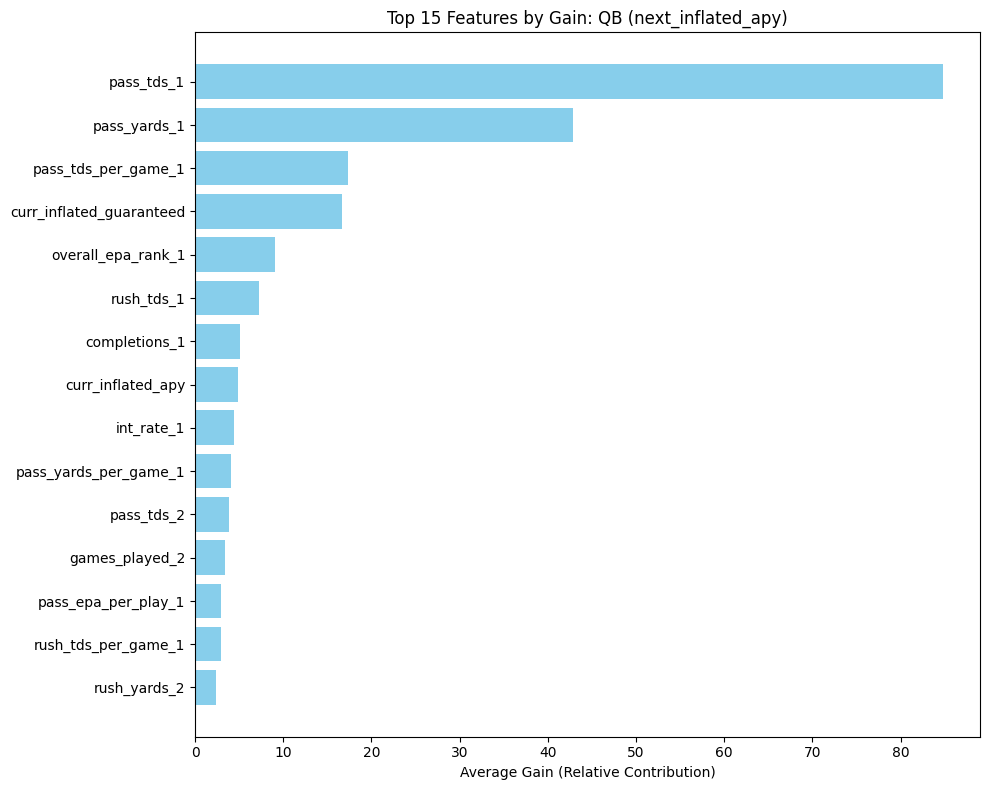

In [0]:
import matplotlib.pyplot as plt

def plot_importance(pos, target='next_inflated_apy'):
    # 1. Access the trained XGBoost model inside the wrapper
    model = final_models[target][pos].regressor_
    
    # 2. Get the gain-based importance dictionary
    # This should already have your names (e.g., 'pass_yards_1') as keys
    importance = model.get_booster().get_score(importance_type='gain')
    
    # 3. Sort and take the top 15
    sorted_importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True)[:15])

    # 4. Plot
    plt.figure(figsize=(10, 8))
    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()), color='skyblue')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Features by Gain: {pos} ({target})")
    plt.xlabel("Average Gain (Relative Contribution)")
    plt.tight_layout()
    plt.show()

# Try it now!
plot_importance('QB')

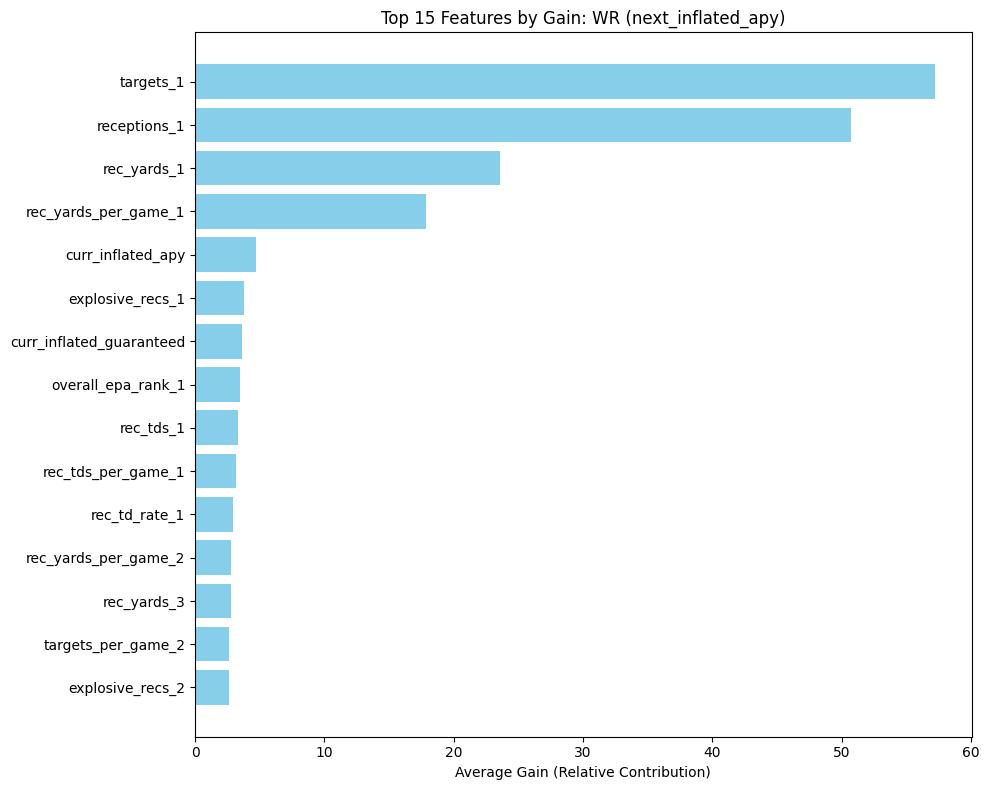

In [0]:
plot_importance('WR')

In [0]:
import joblib
import os

# Get the current working directory of your notebook in the Workspace
notebook_dir = os.getcwd()
save_dir = os.path.join(notebook_dir, "saved_models")

os.makedirs(save_dir, exist_ok=True)

for target, pos_models in final_models.items():
    for pos, model in pos_models.items():
        filename = f"{save_dir}/xgb_{pos}_{target}.joblib"
        joblib.dump(model, filename)
        
print(f"Models saved to: {save_dir}")

Models saved to: /Workspace/Users/getzk021@umn.edu/NFL Contracts Trends Marketplace/saved_models


In [0]:
import joblib
import os
import json
import numpy as np
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor

notebook_dir = os.getcwd()
save_dir = os.path.join(notebook_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

# Loop through all targets and positions to train on 100% of the data
for target in ['next_inflated_apy', 'next_years', 'next_guaranteed']:
    for pos in ['QB', 'WR', 'RB', 'TE']:
        
        # 1. Get 100% of the data for this position
        pos_df = df_clean.filter(pl.col('position') == pos)
        
        if pos_df.height == 0:
            continue
            
        # Reconstruct features list
        current_lagged = [f"{stat}_{lag}" for stat in pos_map[pos] for lag in range(1, 5)]
        current_features = [f for f in static_features if f != 'position'] + current_lagged + ["games_played_1", "games_played_2", "games_played_3", "games_played_4"]
        
        X_full = pos_df.select(current_features).to_pandas()
        y_full = pos_df[target].to_pandas()
        
        # 2. Get the best parameters your RandomizedSearchCV just found
        best_params = final_models[target][pos].regressor_.get_params()
        
        # 3. Create a fresh model using those exact parameters
        # (Removed the duplicate random_state argument here!)
        if target in ['next_inflated_apy', 'next_guaranteed']:
            prod_wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor(**best_params),
                func=np.log1p, inverse_func=np.expm1
            )
        else:
            prod_wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor(**best_params),
                func=None, inverse_func=None
            )
            
        # 4. Train on all the data
        prod_wrapper.fit(X_full, y_full)
        
        # 5. Save the Production Model
        filename = f"{save_dir}/prod_xgb_{pos}_{target}.joblib"
        joblib.dump(prod_wrapper, filename)
        
        # 6. Save the feature list for Streamlit
        with open(f"{save_dir}/features_{pos}.json", "w") as f:
            json.dump({pos: current_features}, f)

print(f"Production Models and Feature Lists successfully trained on 100% of data and saved to: {save_dir}")

Production Models and Feature Lists successfully trained on 100% of data and saved to: /Workspace/Users/getzk021@umn.edu/NFL Contracts Trends Marketplace/saved_models


In [0]:
import pandas as pd
import joblib
import json
import os
import numpy as np

# 1. Use df_clean for prediction math
df_contracts = df_clean.to_pandas()

# 2. Create empty columns for predictions
df_contracts['Pred_APY'] = np.nan
df_contracts['Pred_Years'] = np.nan
df_contracts['Pred_Guaranteed'] = np.nan

save_dir = os.path.join(os.getcwd(), "saved_models")

# 3. Predict Loop
for pos in ['QB', 'WR', 'RB', 'TE']:
    pos_mask = df_contracts['position'] == pos
    if pos_mask.sum() == 0:
        continue
        
    with open(f"{save_dir}/features_{pos}.json", "r") as f:
        current_features = json.load(f)[pos]
        
    X_pos = df_contracts.loc[pos_mask, current_features]
    
    for target, new_col in [('next_inflated_apy', 'Pred_APY'), 
                            ('next_years', 'Pred_Years'), 
                            ('next_guaranteed', 'Pred_Guaranteed')]:
        
        model = joblib.load(f"{save_dir}/prod_xgb_{pos}_{target}.joblib")
        preds = model.predict(X_pos)
        
        round_digits = 1 if target == 'next_years' else 2
        df_contracts.loc[pos_mask, new_col] = np.round(preds, round_digits)

# 4. Create the "Lookup Table" for the final merge
# We keep player and next_year_signed so we know exactly WHERE to stick the prediction
df_predictions_lookup = df_contracts[['player', 'next_year_signed', 'Pred_APY', 'Pred_Years', 'Pred_Guaranteed']]

print(f"Predictions generated for {len(df_predictions_lookup)} contracts.")

Predictions generated for 32742 contracts.


In [0]:
# 1. Calculate Total Values and Total Guarantees (Actual vs Predicted)
df_contracts['Actual_Total_Val'] = df_contracts['next_inflated_apy'] * df_contracts['next_years']
df_contracts['Pred_Total_Val'] = df_contracts['Pred_APY'] * df_contracts['Pred_Years']

# Deltas
df_contracts['Total_Val_Diff'] = df_contracts['Pred_Total_Val'] - df_contracts['Actual_Total_Val']
df_contracts['Guar_Diff'] = df_contracts['Pred_Guaranteed'] - df_contracts['next_inflated_guaranteed']
df_contracts['APY_Diff'] = df_contracts['Pred_APY'] - df_contracts['next_inflated_apy']

# 2. Create the expanded display dataframe (Now including APY)
comparison_df = df_contracts[[
    'player', 'position', 'next_year_signed',
    'next_inflated_apy', 'Pred_APY', 'APY_Diff',
    'Actual_Total_Val', 'Pred_Total_Val', 'Total_Val_Diff',
    'next_inflated_guaranteed', 'Pred_Guaranteed', 'Guar_Diff',
    'next_years', 'Pred_Years'
]].copy()

# 3. Show the Top 5 for each position
for pos in ['QB', 'WR', 'RB', 'TE']:
    print(f"--- {pos} Full Contract Comparison (Top 5 by Predicted Total Value) ---")
    
    pos_df = (comparison_df[comparison_df['position'] == pos]
              .sort_values(by='Pred_Total_Val', ascending=False)
              .head(5))
    
    pos_df = pos_df.round(2)
    
    # Updated column names to include APY
    pos_df.columns = [
        'Player', 'Pos', 'Year', 
        'Actual_APY', 'Model_APY', 'APY_Delta',
        'Actual_Total', 'Model_Total', 'Total_Delta',
        'Actual_Guar', 'Model_Guar', 'Guar_Delta',
        'Actual_Yrs', 'Model_Yrs'
    ]
    
    display(pos_df)

--- QB Full Contract Comparison (Top 5 by Predicted Total Value) ---


Player,Pos,Year,Actual_APY,Model_APY,APY_Delta,Actual_Total,Model_Total,Total_Delta,Actual_Guar,Model_Guar,Guar_Delta,Actual_Yrs,Model_Yrs
Patrick Mahomes,QB,2020,68.39,66.33,-2.06,683.85,583.7,-100.15,95.86,63.48,-32.38,10,8.8
Josh Allen,QB,2021,70.97,64.68,-6.29,425.81,362.21,-63.6,165.04,100.57,-64.47,6,5.6
Josh Allen,QB,2025,59.33,59.23,-0.1,356.0,343.53,-12.47,158.58,146.21,-12.37,6,5.8
Joe Burrow,QB,2023,73.69,69.73,-3.96,368.46,341.68,-26.78,196.3,146.11,-50.19,5,4.9
Justin Herbert,QB,2023,70.34,67.06,-3.28,351.71,328.59,-23.12,179.19,132.34,-46.85,5,4.9


--- WR Full Contract Comparison (Top 5 by Predicted Total Value) ---


Player,Pos,Year,Actual_APY,Model_APY,APY_Delta,Actual_Total,Model_Total,Total_Delta,Actual_Guar,Model_Guar,Guar_Delta,Actual_Yrs,Model_Yrs
Davante Adams,WR,2022,40.51,36.14,-4.37,202.54,166.24,-36.29,32.91,25.01,-7.9,5,4.6
Ja'Marr Chase,WR,2025,43.42,38.0,-5.42,173.69,155.8,-17.89,79.72,74.84,-4.88,4,4.1
Michael Thomas,WR,2019,30.81,32.98,2.17,154.04,155.01,0.97,57.05,32.51,-24.54,5,4.7
CeeDee Lamb,WR,2024,40.1,36.89,-3.21,160.39,151.25,-9.14,79.01,63.44,-15.57,4,4.1
Mike Evans,WR,2018,28.05,30.64,2.59,140.23,150.14,9.9,65.03,40.01,-25.02,5,4.9


--- RB Full Contract Comparison (Top 5 by Predicted Total Value) ---


Player,Pos,Year,Actual_APY,Model_APY,APY_Delta,Actual_Total,Model_Total,Total_Delta,Actual_Guar,Model_Guar,Guar_Delta,Actual_Yrs,Model_Yrs
Ezekiel Elliott,RB,2019,24.01,23.61,-0.4,144.04,108.61,-35.43,44.9,26.84,-18.06,6,4.6
Alvin Kamara,RB,2020,22.8,23.3,0.5,113.98,100.19,-13.79,27.1,17.16,-9.94,5,4.3
Christian McCaffrey,RB,2020,24.34,26.87,2.53,97.36,99.42,2.06,45.69,28.36,-17.33,4,3.7
Todd Gurley,RB,2018,24.43,24.3,-0.13,97.74,87.48,-10.26,37.31,22.72,-14.59,4,3.6
Devonta Freeman,RB,2017,14.88,19.49,4.61,74.4,77.96,3.56,33.0,17.62,-15.38,5,4.0


--- TE Full Contract Comparison (Top 5 by Predicted Total Value) ---


Player,Pos,Year,Actual_APY,Model_APY,APY_Delta,Actual_Total,Model_Total,Total_Delta,Actual_Guar,Model_Guar,Guar_Delta,Actual_Yrs,Model_Yrs
George Kittle,TE,2020,22.8,19.85,-2.95,113.98,95.28,-18.7,45.59,23.32,-22.27,5,4.8
Mark Andrews,TE,2021,23.11,20.72,-2.39,92.42,82.88,-9.54,49.65,20.45,-29.2,4,4.0
Travis Kelce,TE,2016,18.17,15.98,-2.19,90.87,78.3,-12.56,20.4,10.33,-10.07,5,4.9
Travis Kelce,TE,2020,21.75,20.0,-1.75,87.0,76.0,-11.0,31.91,20.46,-11.45,4,3.8
Trey McBride,TE,2025,20.5,18.64,-1.86,81.99,74.56,-7.43,35.06,23.27,-11.79,4,4.0


In [0]:
filtered = df_contracts[
    (df_contracts["curr_year_signed"] >= 2016) &
    (df_contracts["position"].isin(["QB", "RB", "WR", "TE"])) &
    (df_contracts["player"] == "Aaron Rodgers")
]
display(filtered)

player_id,player,position,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,draft_round,draft_overall,draft_year,is_rookie_contract,year_end,next_year_signed,next_apy,next_years,next_value,next_guaranteed,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,contract_idx,anchor_year,next_season_age,pass_attempts_1,pass_attempts_3,pass_attempts_4,pass_attempts_2,completions_1,completions_3,completions_4,completions_2,pass_yards_1,pass_yards_3,pass_yards_4,pass_yards_2,pass_tds_1,pass_tds_3,pass_tds_4,pass_tds_2,interceptions_1,interceptions_3,interceptions_4,interceptions_2,sacks_1,sacks_3,sacks_4,sacks_2,pass_epa_per_play_1,pass_epa_per_play_3,pass_epa_per_play_4,pass_epa_per_play_2,pass_total_epa_1,pass_total_epa_3,pass_total_epa_4,pass_total_epa_2,completion_pct_1,completion_pct_3,completion_pct_4,completion_pct_2,yards_per_attempt_1,yards_per_attempt_3,yards_per_attempt_4,yards_per_attempt_2,pass_td_rate_1,pass_td_rate_3,pass_td_rate_4,pass_td_rate_2,int_rate_1,int_rate_3,int_rate_4,int_rate_2,carries_1,carries_3,carries_4,carries_2,rush_yards_1,rush_yards_3,rush_yards_4,rush_yards_2,rush_tds_1,rush_tds_3,rush_tds_4,rush_tds_2,explosive_runs_1,explosive_runs_3,explosive_runs_4,explosive_runs_2,rush_fumbles_1,rush_fumbles_3,rush_fumbles_4,rush_fumbles_2,rush_epa_per_play_1,rush_epa_per_play_3,rush_epa_per_play_4,rush_epa_per_play_2,rush_total_epa_1,rush_total_epa_3,rush_total_epa_4,rush_total_epa_2,yards_per_carry_1,yards_per_carry_3,yards_per_carry_4,yards_per_carry_2,rush_td_rate_1,rush_td_rate_3,rush_td_rate_4,rush_td_rate_2,explosive_run_rate_1,explosive_run_rate_3,explosive_run_rate_4,explosive_run_rate_2,fumble_rate_1,fumble_rate_3,fumble_rate_4,fumble_rate_2,targets_1,targets_3,targets_4,targets_2,receptions_1,receptions_3,receptions_4,receptions_2,rec_yards_1,rec_yards_3,rec_yards_4,rec_yards_2,rec_tds_1,rec_tds_3,rec_tds_4,rec_tds_2,explosive_recs_1,explosive_recs_3,explosive_recs_4,explosive_recs_2,rec_fumbles_1,rec_fumbles_3,rec_fumbles_4,rec_fumbles_2,air_yards_1,air_yards_3,air_yards_4,air_yards_2,yac_1,yac_3,yac_4,yac_2,rec_epa_per_play_1,rec_epa_per_play_3,rec_epa_per_play_4,rec_epa_per_play_2,rec_total_epa_1,rec_total_epa_3,rec_total_epa_4,rec_total_epa_2,catch_rate_1,catch_rate_3,catch_rate_4,catch_rate_2,yards_per_rec_1,yards_per_rec_3,yards_per_rec_4,yards_per_rec_2,rec_td_rate_1,rec_td_rate_3,rec_td_rate_4,rec_td_rate_2,explosive_rec_rate_1,explosive_rec_rate_3,explosive_rec_rate_4,explosive_rec_rate_2,air_yards_per_target_1,air_yards_per_target_3,air_yards_per_target_4,air_yards_per_target_2,yac_per_rec_1,yac_per_rec_3,yac_per_rec_4,yac_per_rec_2,games_played_1,games_played_3,games_played_4,games_played_2,pass_epa_rank_1,pass_epa_rank_3,pass_epa_rank_4,pass_epa_rank_2,rush_epa_rank_1,rush_epa_rank_3,rush_epa_rank_4,rush_epa_rank_2,rec_epa_rank_1,rec_epa_rank_3,rec_epa_rank_4,rec_epa_rank_2,overall_epa_rank_1,overall_epa_rank_3,overall_epa_rank_4,overall_epa_rank_2,pass_yards_per_game_1,pass_yards_per_game_3,pass_yards_per_game_4,pass_yards_per_game_2,pass_tds_per_game_1,pass_tds_per_game_3,pass_tds_per_game_4,pass_tds_per_game_2,carries_per_game_1,carries_per_game_3,carries_per_game_4,carries_per_game_2,rush_yards_per_game_1,rush_yards_per_game_3,rush_yards_per_game_4,rush_yards_per_game_2,rush_tds_per_game_1,rush_tds_per_game_3,rush_tds_per_game_4,rush_tds_per_game_2,targets_per_game_1,targets_per_game_3,targets_per_game_4,targets_per_game_2,receptions_per_game_1,receptions_per_game_3,receptions_per_game_4,receptions_per_game_2,rec_yards_per_game_1,rec_yards_per_game_3,rec_yards_per_game_4,rec_yards_per_game_2,rec_tds_per_game_1,rec_tds_per_game_3,rec_tds_per_game_4,rec_tds_per_game_2,yearly_cap,career_year_at_signing,Pred_APY,Pred_Years,Pred_Guaranteed,Actual_Total_Val,Pred_Total_Val,Total_Val_Diff,Guar_Diff,APY_Diff
00-0023459,Aaron Rodgers,QB,2018,4.0,134.0,33.5,78.7,false

In [0]:
import pandas as pd
import numpy as np

def create_master_dashboard_v4(player_season, df_contracts):
    # --- 1. CONVERT AND SETUP ---
    if hasattr(player_season, "to_pandas"):
        stats_df = player_season.to_pandas()
    else:
        stats_df = player_season.copy()

    # Position/Year Filter
    stats_df = stats_df[stats_df['position'].isin(['QB', 'WR', 'RB', 'TE'])]
    stats_df = stats_df[(stats_df['season'] >= 2015) & (stats_df['season'] <= 2025)]

    # --- 2. MASTER NAME FIX (The "Contract Name" Change) ---
    # Create a mapping of player_id -> Full Name from df_contracts
    contract_names = df_contracts[['player_id', 'player']].drop_duplicates('player_id')
    name_map = dict(zip(contract_names['player_id'], contract_names['player']))
    
    # Apply the full name to stats_df, fallback to player_name if not found
    stats_df['preferred_name'] = stats_df['player_id'].map(name_map)
    if 'player_name' in stats_df.columns:
        stats_df['preferred_name'] = stats_df['preferred_name'].fillna(stats_df['player_name'])
    
    # Rename for consistency and drop the old abbreviated name
    stats_df = stats_df.drop(columns=['player_name', 'player'], errors='ignore')
    stats_df = stats_df.rename(columns={'preferred_name': 'player'})

    # --- 3. POSITION-SPECIFIC DEDUPLICATION ---
    # Throw away exact duplicate chunks, but keep unique segments to be summed later
    qb_keys = ['player_id', 'season', 'pass_attempts', 'pass_yards', 'pass_tds', 'interceptions']
    rb_keys = ['player_id', 'season', 'carries', 'rush_yards', 'rush_tds']
    wr_te_keys = ['player_id', 'season', 'targets', 'receptions', 'rec_yards', 'rec_tds']

    qbs = stats_df[stats_df['position'] == 'QB'].drop_duplicates(subset=qb_keys)
    rbs = stats_df[stats_df['position'] == 'RB'].drop_duplicates(subset=rb_keys)
    wrs_tes = stats_df[stats_df['position'].isin(['WR', 'TE'])].drop_duplicates(subset=wr_te_keys)

    unique_chunks = pd.concat([qbs, rbs, wrs_tes])

    # --- 4. AGGREGATE SEGMENTS ---
    volume_cols = [
        'pass_attempts', 'completions', 'pass_yards', 'pass_tds', 'interceptions', 'sacks',
        'carries', 'rush_yards', 'rush_tds', 'explosive_runs', 'rush_fumbles',
        'targets', 'receptions', 'rec_yards', 'rec_tds', 'explosive_recs', 'rec_fumbles',
        'air_yards', 'yac', 'games_played', 'total_epa', 'pass_total_epa', 'rush_total_epa', 'rec_total_epa'
    ]
    all_stat_cols = [c for c in stats_df.columns if c not in ['player_id', 'season', 'player', 'position']]
    rate_cols = [c for c in all_stat_cols if c not in volume_cols]

    agg_dict = {col: 'sum' for col in volume_cols if col in unique_chunks.columns}
    agg_dict.update({col: 'mean' for col in rate_cols if col in unique_chunks.columns})
    
    stats_clean = unique_chunks.groupby(['player_id', 'season', 'player', 'position'], as_index=False).agg(agg_dict)

    # --- 5. PREP CONTRACT DATA ---
    contract_cols = [
        'player_id', 'next_year_signed', 
        'Pred_APY', 'next_inflated_apy', 'APY_Diff',
        'Pred_Total_Val', 'Actual_Total_Val', 'Total_Val_Diff',
        'Pred_Guaranteed', 'next_inflated_guaranteed', 'Guar_Diff',
        'Pred_Years', 'next_years'
    ]
    contracts_clean = df_contracts[contract_cols].copy()

    # --- 6. JOINS ---
    # Join Actual Contract Info (Year Signed)
    df_master = pd.merge(
        stats_clean,
        contracts_clean,
        left_on=['player_id', 'season'],
        right_on=['player_id', 'next_year_signed'],
        how='left'
    )

    # Join Model Valuation (Prediction for Next Year)
    eval_join = df_contracts[['player_id', 'next_year_signed', 'Pred_APY']].copy()
    eval_join['stats_season'] = eval_join['next_year_signed'] - 1
    
    df_master = pd.merge(
        df_master,
        eval_join[['player_id', 'stats_season', 'Pred_APY']],
        left_on=['player_id', 'season'],
        right_on=['player_id', 'stats_season'],
        how='left'
    ).rename(columns={'Pred_APY_y': 'Model_Valuation_Next_Year', 'Pred_APY_x': 'Pred_APY'})

    # --- 7. FORWARD FILL & DELTA ---
    df_master = df_master.sort_values(['player_id', 'season'])
    fill_cols = ['next_inflated_apy', 'next_years', 'Actual_Total_Val', 'next_inflated_guaranteed']
    df_master[fill_cols] = df_master.groupby('player_id')[fill_cols].ffill()

    df_master['Performance_vs_Pay_Delta'] = df_master['Model_Valuation_Next_Year'] - df_master['next_inflated_apy']

    # Final Cleanup and Export
    df_master = df_master.drop(columns=['next_year_signed', 'stats_season'], errors='ignore')
    return df_master.sort_values(['player', 'season'], ascending=[True, False]).round(2)

# Create the final dashboard
final_dashboard_df = create_master_dashboard_v4(player_season, df_contracts)

In [0]:
contracts

player,position,team,is_active,year_signed,years,value,apy,guaranteed,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,player_page,otc_id,gsis_id,date_of_birth,height,weight,college,draft_year,draft_round,draft_overall,draft_team,cols
str,str,str,bool,i32,i32,f64,f64,f64,f64,f64,f64,f64,str,i32,str,str,str,str,str,i32,i32,i32,str,list[struct[13]]
"""Joe Burrow""","""QB""","""Bengals""",true,2023,5,275.0,55.0,146.51,0.245,368.460854,73.692171,196.302544,"""https://overthecap.com/player/…",8741,"""00-0036442""",null,"""6'4""""","""215""","""LSU""",2020,1,1,"""Bengals""","[{""2020"",""Bengals"",0.61,5.970025,0.0,0.61,6.580025,0.032,24.4901,null,null,null,0.0}, {""2021"",""Bengals"",0.78,5.970025,1.475006,2.255006,8.225035,0.042,2.255006,null,null,null,0.0}, … {""Total"",""Total"",325.299,62.965582,11.515036,91.825018,339.779622,null,340.694136,null,null,null,90.0}]"
"""Aaron Rodgers""","""QB""","""GB/NYJ""",false,2022,5,150.815,50.271667,101.415,0.241,218.181931,72.727311,146.715648,"""https://overthecap.com/player/…",1085,"""00-0023459""","""December 2, 1983""","""6'2""""","""225""","""California""",2005,1,24,"""Packers""","[{""2005"",""Packers"",0.23,0.3,0.62,0.62,1.15,0.013,2.35,0.0,null,0.0,null}, {""2006"",""Packers"",0.35,1.0525,0.0,0.0,1.4025,0.014,3.36,0.0,null,0.0,null}, … {""Total"",""Total"",91.015,145.821136,60.28,73.51,306.016136,null,395.812794,6.6,null,2.3,null}]"
"""Josh Allen""","""QB""","""Bills""",false,2021,6,258.0,43.0,100.0,0.236,425.806027,70.967671,165.041096,"""https://overthecap.com/player/…",6892,"""00-0034857""",null,"""6'5""""","""233""","""Wyoming""",2018,1,7,"""Bills""","[{""2018"",""Bills"",0.48,3.371461,0.0,0.48,3.851461,0.02,13.965844,0.0,null,null,0.0}, {""2019"",""Bills"",0.57,3.371461,0.872865,1.442865,4.814326,0.024,1.442865,0.0,null,null,0.0}, … {""Total"",""Total"",343.08,183.650255,70.23719,69.22719,482.904439,null,479.404439,4.0,null,null,136.94}]"
"""Russell Wilson""","""QB""","""Broncos""",false,2022,5,245.0,49.0,124.0,0.235,354.43804,70.887608,179.389049,"""https://overthecap.com/player/…",1569,"""00-0029263""","""November 29, 1988""","""5'11""""","""206""","""Wisconsin""",2012,3,75,"""Seahawks""","[{""2012"",""Seahawks"",0.39,0.154868,0.0,0.0,0.544868,0.005,1.009472,0.0,0.0,null,0.0}, {""2013"",""Seahawks"",0.526217,0.154868,0.0,0.0,0.681085,0.005,0.526217,0.0,0.0,null,0.0}, … {""Total"",""Total"",86.105651,104.879766,5.0,84.492,206.579535,null,278.050123,0.5,0.529412,null,4.0}]"
"""Dak Prescott""","""QB""","""Cowboys""",true,2024,4,240.0,60.0,129.0,0.235,283.038371,70.759593,152.133125,"""https://overthecap.com/player/…",4848,"""00-0033077""",null,"""6'2""""","""226""","""Mississippi State""",2016,4,135,"""Cowboys""","[{""2016"",""Cowboys"",0.45,0.095848,null,0.0,0.545848,0.003,0.833392,null,null,null,null}, {""2017"",""Cowboys"",0.54,0.095848,null,0.0,0.635848,0.004,0.54,null,null,null,null}, … {""Total"",""Total"",467.589,276.628781,null,89.050667,425.759448,null,435.437392,null,null,null,null}]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Jorgen Hus""","""LS""","""Chiefs""",false,0,2,0.96,0.48,0.0,0.0,0.0,0.0,0.0,"""https://overthecap.com/player/…",2913,"""00-0029766""","""September 12, 1989""","""6'1""""","""233""","""Regina - Canada""",2013,null,null,"""Rams""",null
"""Trevor Gillette""","""LS""","""Jaguars""",false,0,4,1.53,0.51,0.0,0.0,0.0,0.0,0.0,"""https://overthecap.com/player/…",3417,null,null,null,null,"""Rice""",2014,null,null,"""Jaguars""",null
"""Nate Boyer""","""LS""","""Seahawks""",false,0,3,1.5775,0.525833,0.0025,0.0,0.0,0.0,0.0,"""https://overthecap.com/player/…",4513,"""00-0031892""","""January 9, 1981""","""5'10""""","""195""","""Texas""",2015,null,null,"""Seahawks""",null


In [0]:
import pandas as pd

# 1. Convert pbp_reg to pandas if needed
if hasattr(pbp_reg, "to_pandas"):
    pbp_df = pbp_reg.to_pandas()
else:
    pbp_df = pbp_reg.copy()

# 2. Identify all possible ID columns in PBP
# nflverse uses these specific names for different play types
id_cols = ['passer_id', 'rusher_id', 'receiver_id']
existing_ids = [c for c in id_cols if c in pbp_df.columns]

# 3. Create a long-format list of player_id + season + team
# We stack the different ID columns into one 'player_id' column
team_map_raw = pd.concat([
    pbp_df[['season', 'posteam', col]].rename(columns={col: 'player_id'})
    for col in existing_ids
]).dropna(subset=['player_id', 'posteam'])

# 4. Find the most frequent team (mode) for each player per season
# This handles players who were traded mid-season
team_map = (
    team_map_raw.groupby(['player_id', 'season'])['posteam']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'posteam': 'team'})
)

print("Team map created successfully!")

Team map created successfully!


In [0]:
# Assuming you already ran create_master_dashboard_core
final_dashboard_df = pd.merge(final_dashboard_df, team_map, on=['player_id', 'season'], how='left')

In [0]:
# 1. Sort by ID and Season (Ascending to fill from past to future)
final_dashboard_df = final_dashboard_df.sort_values(['player_id', 'season'], ascending=True)

# 2. Forward fill only (grouped by player)
contract_cols = ['next_inflated_apy', 'next_years', 'Actual_Total_Val', 'next_inflated_guaranteed']
final_dashboard_df[contract_cols] = final_dashboard_df.groupby('player_id')[contract_cols].ffill()

# 3. Recalculate Delta (only where we have a valid pay number)
final_dashboard_df['Performance_vs_Pay_Delta'] = (
    final_dashboard_df['Model_Valuation_Next_Year'] - final_dashboard_df['next_inflated_apy']
)

# 4. Sort back to Dashboard view (Newest first)
final_dashboard_df = final_dashboard_df.sort_values(['player', 'season'], ascending=[True, False])

In [0]:
# CHECK 2025
filtered = final_dashboard_df[
    final_dashboard_df["player"] == "Aaron Rodgers"
]

display(filtered.astype(object))

player_id,season,player,position,pass_attempts,completions,pass_yards,pass_tds,interceptions,sacks,carries,rush_yards,rush_tds,explosive_runs,rush_fumbles,targets,receptions,rec_yards,rec_tds,explosive_recs,rec_fumbles,air_yards,yac,games_played,total_epa,pass_total_epa,rush_total_epa,rec_total_epa,pass_epa_per_play,completion_pct,yards_per_attempt,pass_td_rate,int_rate,rush_epa_per_play,yards_per_carry,rush_td_rate,explosive_run_rate,fumble_rate,rec_epa_per_play,catch_rate,yards_per_rec,rec_td_rate,explosive_rec_rate,air_yards_per_target,yac_per_rec,overall_epa_rank,pass_epa_rank,rush_epa_rank,rec_epa_rank,pass_yards_per_game,pass_tds_per_game,carries_per_game,rush_yards_per_game,rush_tds_per_game,targets_per_game,receptions_per_game,rec_yards_per_game,rec_tds_per_game,Pred_APY,next_inflated_apy,APY_Diff,Pred_Total_Val,Actual_Total_Val,Total_Val_Diff,Pred_Guaranteed,next_inflated_guaranteed,Guar_Diff,Pred_Years,next_years,Model_Valuation_Next_Year,Performance_vs_Pay_Delta,team
00-0023459,2025,Aaron Rodgers,QB,491.0,327.0,3322.0,24.0,7.0,29.0,21.0,61.0,1.0,2,2.0,1.0,1.0,-9.0,0.0,0,0.0,-9.0,0.0,16,9.74,14.22,-2.95,-1.53,0.03,0.67,6.77,0.05,0.01,-0.14,2.9,0.05,0.1,0.1,-1.53,1.0,-9.0,0.0,0.0,-9.0,0.0,27.0,21.0,59.0,10.0,207.62,1.5,1.31,3.81,0.06,0.06,0.06,-0.56,0.0,15.59,14.73,0.86,21.83,14.73,7.1,9.97,10.79,-0.82,1.4,1.0,null,null,PIT
00-0023459,2024,Aaron Rodgers,QB,573.0,368.0,3897.0,28.0,11.0,40.0,22.0,107.0,0.0,4,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,17,3.02,-1.26,4.28,0.0,-0.0,0.64,6.8,0.05,0.02,0.19,4.86,0.0,0.18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,39.0,25.0,4.0,229.24,1.65,1.29,6.29,0.0,0.0,0.0,0.0,0.0,null,50.24,null,null,150.73,null,null,100.49,null,null,3.0,15.59,-34.650000000000006,NYJ
00-0023459,2023,Aaron Rodgers,QB,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1,-2.03,-2.03,0.0,0.0,-1.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,39.0,39.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.69,50.24,-13.55,91.72,150.73,-59.01,73.98,100.49,-26.51,2.5,3.0,null,null,NYJ
00-0023459,2022,Aaron Rodgers,QB,530.0,350.0,3695.0,26.0,12.0,32.0,34.0,94.0,1.0,4,3.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,17,-25.86,-18.05,-7.81,0.0,-0.03,0.66,6.97,0.05,0.02,-0.23,2.76,0.03,0.12,0.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,61.0,67.0,4.0,217.35,1.53,2.0,5.53,0.06,0.0,0.0,0.0,0.0,59.66,72.73,-13.07,280.4,363.64,-83.23,101.59,146.72,-45.13,4.7,5.0,36.69,-36.040000000000006,GB
00-0023459,2021,Aaron Rodgers,QB,527.0,366.0,4115.0,37.0,4.0,30.0,36.0,94.0,4.0,4,0.0,2.0,2.0,-8.0,0.0,0,0.0,-8.0,0.0,32,140.74,128.82,14.4,-2.49,0.23,0.69,7.8,0.07,0.01,0.4,2.61,0.11,0.11,0.0,-1.24,1.0,-4.0,0.0,0.0,-4.0,0.0,11.5,10.0,15.0,6.0,128.59,1.16,1.12,2.94,0.12,0.06,0.06,-0.25,0.0,null,56.94,null,null,227.77,null,null,133.77,null,null,4.0,59.66,2.719999999999999,GB
00-0023459,2020,Aaron Rodgers,QB,521.0,372.0,4299.0,48.0,5.0,20.0,38.0,149.0,3.0,4,3.0,1.0,1.0,-6.0,0.0,0,0.0,-4.0,-2.0,16,177.33,175.75,2.94,-1.36,0.32,0.71,8.25,0.09,0.01,0.08,3.92,0.08,0.11,0.08,-1.36,1.0,-6.0,0.0,0.0,-4.0,-2.0,2.0,1.0,23.0,12.0,268.69,3.0,2.38,9.31,0.19,0.06,0.06,-0.38,0.0,null,56.94,null,null,227.77,null,null,133.77,null,null,4.0,null,null,GB
00-0023459,2019,Aaron Rodgers,QB,565.0,353.0,4002.0,26.0,4.0,36.0,47.0,183.0,1.0,9,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,16,45.3,45.08,0.23,0.0,0.07,0.62,7.08,0.05,0.01,0.0,3.89,0.02,0.19,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,14.0,30.0,5.0,250.12,1.62,2.94,11.44,0.06,0.0,0.0,0.0,0.0,null,56.94,null,null,227.77,null,null,133.77,null,null,4.0,null,null,GB
00-0023459,2018,Aaron Rodgers,QB,595.0,372.0,4442.0,25.0,2.0,49.0,44.0,269.0,2.0,10,2.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,16,72.76,50.11,22.65,0.0,0.08,0.63,7.47,0.04,0.0,0.51,6.11,0.05,0.23,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,10.0,3.0,8.0,277.62,1.56,2.75,16.81,0.12,0.0,0.0,0.0,0.0,56.35,56.94,-0.59,231.03,227.77,3.27,79.46,133.77,-54.31,4.1,4.0,null,null,GB
00-0023459,2017,Aaron Rodgers,QB,232.0,154.0,1675.0,16.0,6.0,22.0,24.0,126.0,0.0,4,1.0,0.0,0.0,0.0,0.0,0,0.0

In [0]:
# Final cleanup and save to CSV
final_dashboard_df.round(2).to_csv("complete_final_data.csv", index=False)